# 📊 Data Visualization — Part 1
## Monthly Weather Statistics for Major Cities (2024)

This notebook demonstrates **matplotlib** and **seaborn** visualizations using synthetic weather data for five cities:
Kyiv, London, New York, Tokyo, and Sydney.

We will create the following chart types:
1. **Line Plot** — Average monthly temperature trends
2. **Bar Chart** — Total annual rainfall by city
3. **Histogram** — Distribution of daily wind speeds
4. **Stacked Area Chart** — Monthly sunshine hours by city

In [2]:
# ── Imports ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global style for all charts
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


In [3]:
# ── Generate Synthetic Weather Dataset ────────────────────
np.random.seed(42)

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

cities = ["Kyiv", "London", "New York", "Tokyo", "Sydney"]

# Average monthly temperatures (°C) — realistic base curves + noise
temp_base = {
    "Kyiv":     [-4, -3,  3, 11, 17, 20, 22, 21, 15,  8,  2, -2],
    "London":   [ 5,  5,  8, 11, 14, 17, 19, 19, 16, 12,  8,  5],
    "New York": [ 1,  2,  7, 13, 18, 23, 26, 25, 21, 15,  9,  3],
    "Tokyo":    [ 5,  6, 10, 15, 19, 23, 27, 28, 24, 18, 13,  8],
    "Sydney":   [23, 23, 22, 19, 16, 14, 13, 14, 16, 18, 20, 22],
}

# Build a tidy DataFrame for temperatures
temp_rows = []
for city in cities:
    for i, month in enumerate(months):
        temp_rows.append({
            "City": city,
            "Month": month,
            "Month_num": i + 1,
            "Temperature_C": temp_base[city][i] + np.random.normal(0, 0.8)
        })

df_temp = pd.DataFrame(temp_rows)

# Annual rainfall (mm) per city
rainfall_data = {
    "City": cities,
    "Rainfall_mm": [620, 750, 1270, 1530, 1220]
}
df_rain = pd.DataFrame(rainfall_data)

# Daily wind speed observations (km/h) — 365 readings per city
wind_records = []
wind_means = {"Kyiv": 12, "London": 18, "New York": 16, "Tokyo": 14, "Sydney": 20}
for city in cities:
    speeds = np.random.gamma(shape=3, scale=wind_means[city] / 3, size=365)
    for s in speeds:
        wind_records.append({"City": city, "Wind_kmh": round(s, 1)})
df_wind = pd.DataFrame(wind_records)

# Monthly sunshine hours
sunshine_base = {
    "Kyiv":     [ 50,  70, 120, 170, 240, 270, 290, 270, 190, 120,  60,  40],
    "London":   [ 55,  75, 110, 155, 200, 210, 215, 200, 155, 110,  65,  45],
    "New York": [155, 160, 210, 225, 260, 275, 290, 270, 235, 210, 160, 145],
    "Tokyo":    [180, 165, 175, 180, 190, 130, 155, 185, 130, 135, 150, 175],
    "Sydney":   [240, 210, 215, 195, 175, 155, 165, 190, 210, 230, 235, 245],
}
df_sun = pd.DataFrame(sunshine_base, index=months)

print(f"Temperature rows : {len(df_temp)}")
print(f"Rainfall rows    : {len(df_rain)}")
print(f"Wind speed rows  : {len(df_wind)}")
print(f"Sunshine table   : {df_sun.shape}")

Temperature rows : 60
Rainfall rows    : 5
Wind speed rows  : 1825
Sunshine table   : (12, 5)


---
## 1 · Line Plot — Average Monthly Temperature

A **line plot** is the natural choice for showing how a continuous variable changes over an ordered
sequence (time). Here we compare the temperature curves of five cities across 12 months to reveal
seasonal patterns and hemispheric differences (Sydney's curve is inverted).

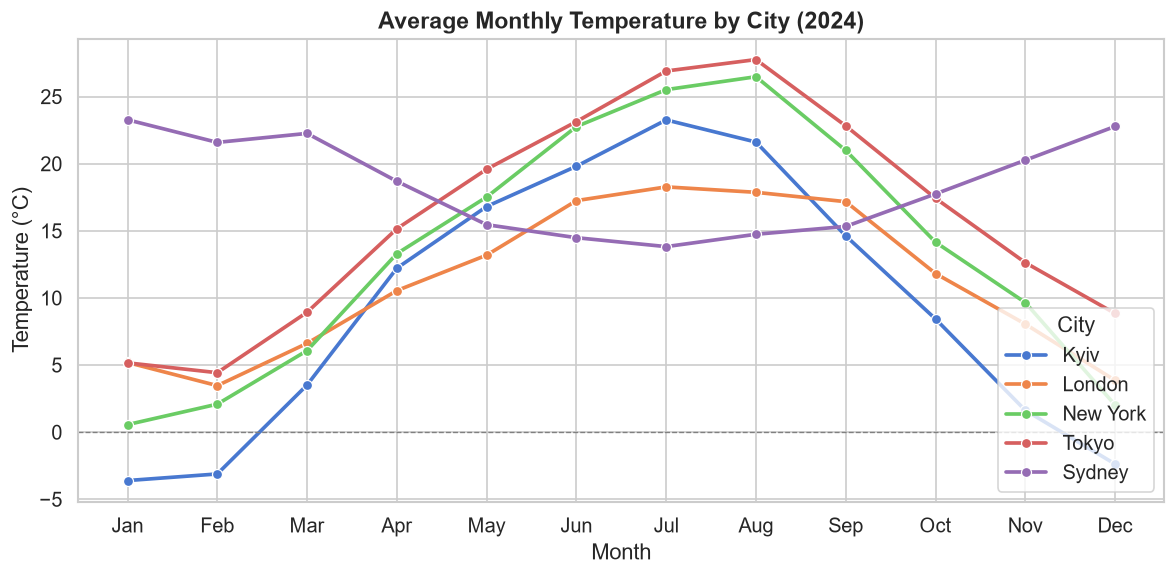

In [4]:
# ── 1. Line Plot: Monthly Temperature ───────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=df_temp,
    x="Month_num", y="Temperature_C", hue="City",
    marker="o", linewidth=2.2, ax=ax
)

# Formatting
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_xlabel("Month")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Average Monthly Temperature by City (2024)", fontsize=14, fontweight="bold")
ax.legend(title="City", loc="lower right")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")  # freezing line

plt.tight_layout()
plt.show()

---
## 2 · Bar Chart — Total Annual Rainfall

A **bar chart** is ideal for comparing a single numeric value across discrete categories.
We compare the total annual rainfall (in mm) for each city. This helps identify
which cities are significantly wetter or drier.

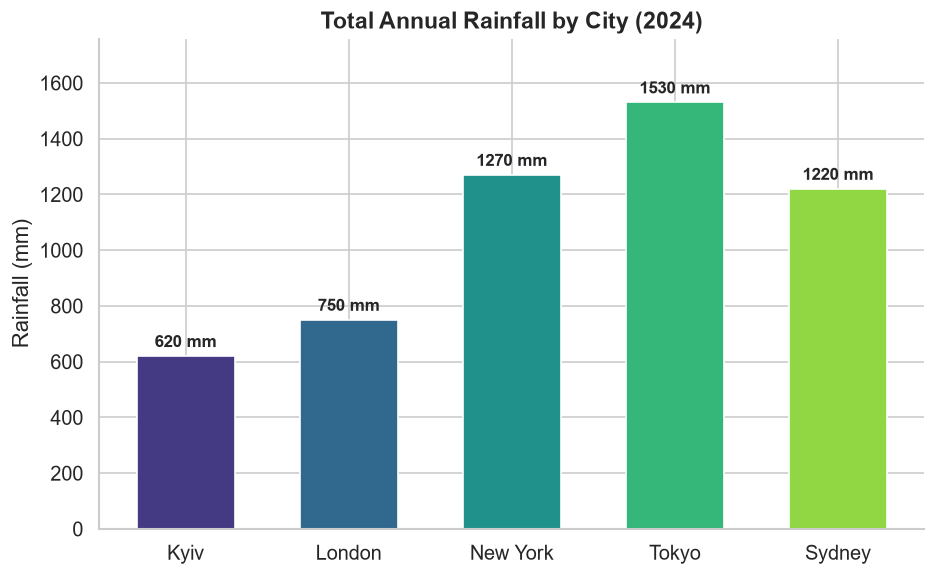

In [5]:
# ── 2. Bar Chart: Annual Rainfall ────────────────────────
colors = sns.color_palette("viridis", n_colors=len(cities))

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(df_rain["City"], df_rain["Rainfall_mm"], color=colors, edgecolor="white", width=0.6)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 20,
            f"{int(height)} mm", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Rainfall (mm)")
ax.set_title("Total Annual Rainfall by City (2024)", fontsize=14, fontweight="bold")
ax.set_ylim(0, max(df_rain["Rainfall_mm"]) * 1.15)  # extra space for labels

# Remove top & right spines for cleaner look
sns.despine()

plt.tight_layout()
plt.show()

---
## 3 · Histogram — Distribution of Daily Wind Speeds

A **histogram** reveals the shape of a distribution. By overlaying histograms (or using KDE curves)
for each city we can compare how wind speeds are distributed — e.g., whether a city tends toward
calm or gusty conditions.

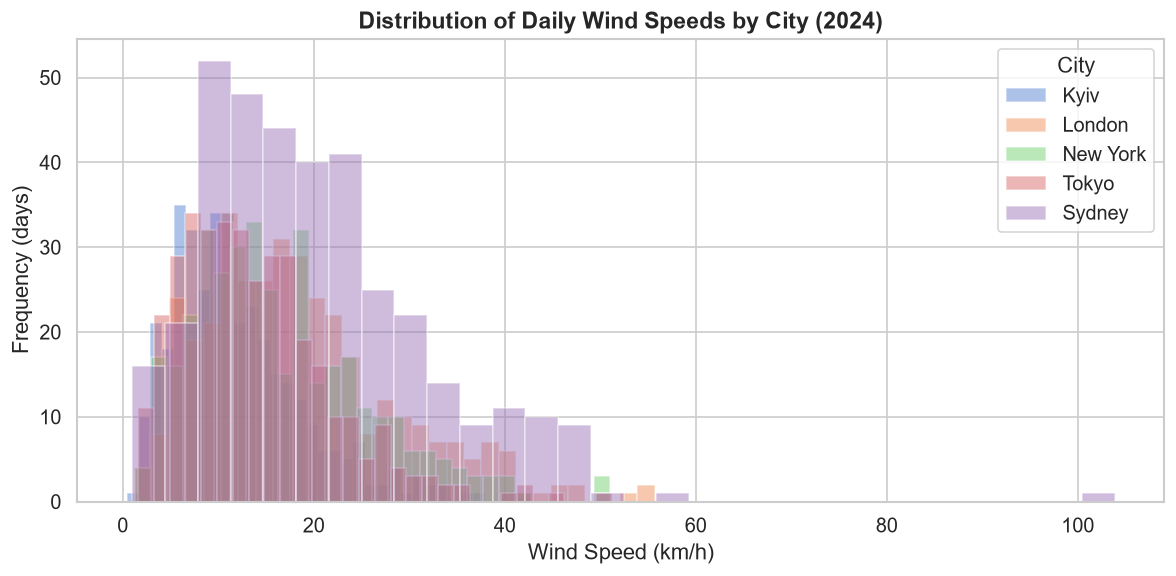

In [6]:
# ── 3. Histogram: Daily Wind Speed Distribution ──────────
fig, ax = plt.subplots(figsize=(10, 5))

for city in cities:
    subset = df_wind[df_wind["City"] == city]["Wind_kmh"]
    ax.hist(subset, bins=30, alpha=0.45, label=city, edgecolor="white")

ax.set_xlabel("Wind Speed (km/h)")
ax.set_ylabel("Frequency (days)")
ax.set_title("Distribution of Daily Wind Speeds by City (2024)", fontsize=14, fontweight="bold")
ax.legend(title="City")

plt.tight_layout()
plt.show()

---
## 4 · Stacked Area Chart — Monthly Sunshine Hours

A **stacked area chart** shows both individual contributions and the cumulative total over time.
Here it highlights how each city contributes to the combined sunshine hours month by month,
making seasonal peaks easy to spot.

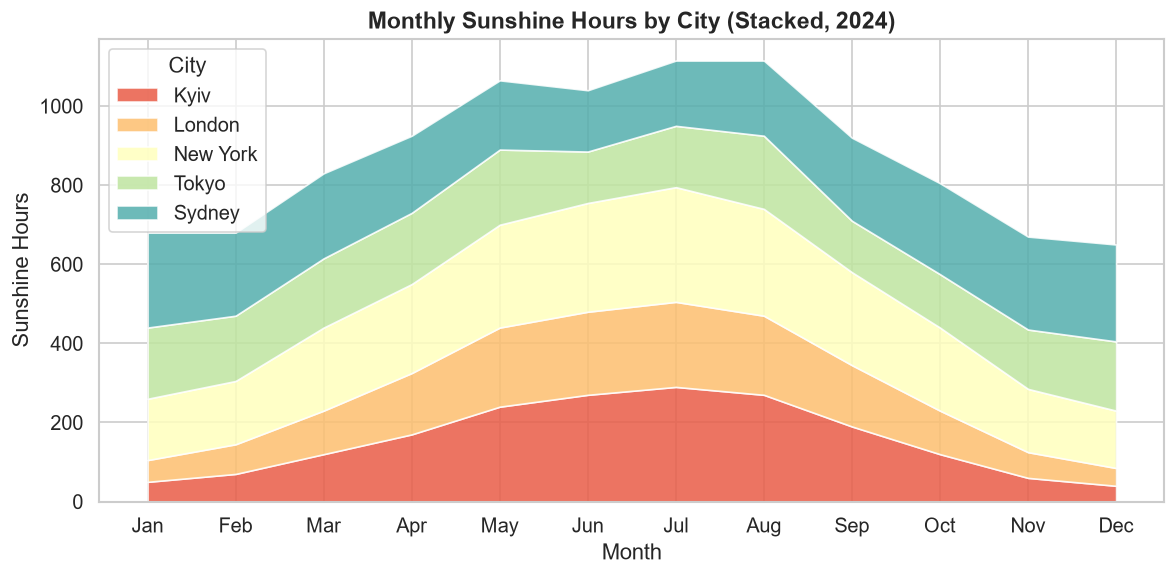

In [7]:
# ── 4. Stacked Area Chart: Sunshine Hours ────────────────
fig, ax = plt.subplots(figsize=(10, 5))

palette = sns.color_palette("Spectral", n_colors=len(cities))

ax.stackplot(
    range(12),
    [df_sun[city].values for city in cities],
    labels=cities,
    colors=palette,
    alpha=0.85
)

ax.set_xticks(range(12))
ax.set_xticklabels(months)
ax.set_xlabel("Month")
ax.set_ylabel("Sunshine Hours")
ax.set_title("Monthly Sunshine Hours by City (Stacked, 2024)", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", title="City")

plt.tight_layout()
plt.show()

---
*End of Notebook 1*